# Import Data

In [3]:
import pandas as pd
import numpy as np

In [4]:
import re

def extract_drive_id(url):
    """
    Hàm nhận vào URL Google Drive và trả về File ID
    Hỗ trợ cả dạng /file/d/ và open?id=
    """
    patterns = [
        r"https://drive\.google\.com/file/d/([a-zA-Z0-9_-]+)",  # dạng /file/d/ID
        r"id=([a-zA-Z0-9_-]+)"                                  # dạng ?id=ID
    ]

    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    return None

# Sử dụng
url = "https://drive.google.com/open?id=1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM&usp=drive_copy"
file_id = extract_drive_id(url)

if file_id:
    print("🎯 File ID extracted:", file_id)
else:
    print("❌ Không tìm thấy file ID từ link.")

# Bạn có thể dùng luôn với gdown:
import gdown
gdown.download(f"https://drive.google.com/uc?id={file_id}", "du_lieu_vong_2.xlsx", quiet=False)


🎯 File ID extracted: 1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM


FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM

but Gdown can't. Please check connections and permissions.

In [ ]:
import pandas as pd

# Đường dẫn đến file (nếu đã tải về Colab)
file_path = "du_lieu_vong_2.xlsx"

# Đọc từng sheet
balance_sheet = pd.read_excel(file_path, sheet_name='1. Balance Sheet')
income_statement = pd.read_excel(file_path, sheet_name='2. Income Statement')
cash_flow = pd.read_excel(file_path, sheet_name='3. Cash Flow')

In [ ]:
balance_sheet.info()

In [ ]:
income_statement.info()

In [ ]:
cash_flow.info()

# Analysis

In [ ]:
# Thực hiện join 3 bảng theo 'Công ty' và 'Năm'
merged_df = balance_sheet.merge(income_statement, on=['Công ty', 'Năm'], how='outer') \
                      .merge(cash_flow, on=['Công ty', 'Năm'], how='outer')

# Hiển thị kết quả

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 40 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Công ty                                        8010 non-null   int64  
 1   Năm                                            8010 non-null   int64  
 2   A. TÀI SẢN NGẮN HẠN                            8007 non-null   float64
 3   I. Tiền và các khoản tương đương tiền          7988 non-null   float64
 4   II. Đầu tư tài chính ngắn hạn                  4045 non-null   float64
 5   III. Các khoản phải thu ngắn hạn               5544 non-null   float64
 6   IV. Hàng tồn kho                               5881 non-null   float64
 7   V. Tài sản ngắn hạn khác                       6769 non-null   float64
 8   B. TÀI SẢN DÀI HẠN                             7481 non-null   float64
 9   I. Các khoản phải thu dài hạn                  1358 

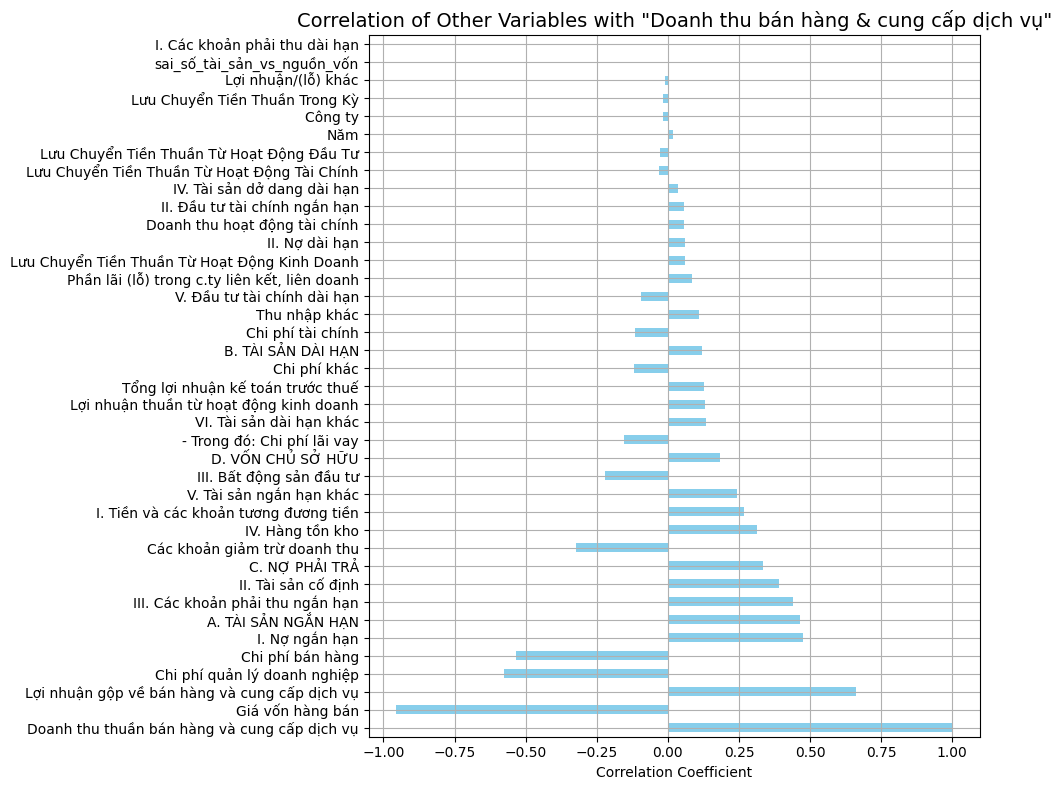

In [ ]:
# Tên chính xác của cột cần tìm
target_column = "Doanh thu bán hàng & cung cấp dịch vụ"

# Tính hệ số tương quan giữa cột này và tất cả các cột còn lại
correlations = numeric_df.corr()[target_column].drop(target_column).sort_values(key=abs, ascending=False)

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='skyblue')
plt.title(f'Correlation of Other Variables with "{target_column}"', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
merged_df.isna().sum()

,0
Công ty,0
Năm,0
A. TÀI SẢN NGẮN HẠN,3
I. Tiền và các khoản tương đương tiền,22
II. Đầu tư tài chính ngắn hạn,3965
III. Các khoản phải thu ngắn hạn,2466
IV. Hàng tồn kho,2129
V. Tài sản ngắn hạn khác,1241
B. TÀI SẢN DÀI HẠN,529
I. Các khoản phải thu dài hạn,6652


NameError: name 'income_statement' is not defined

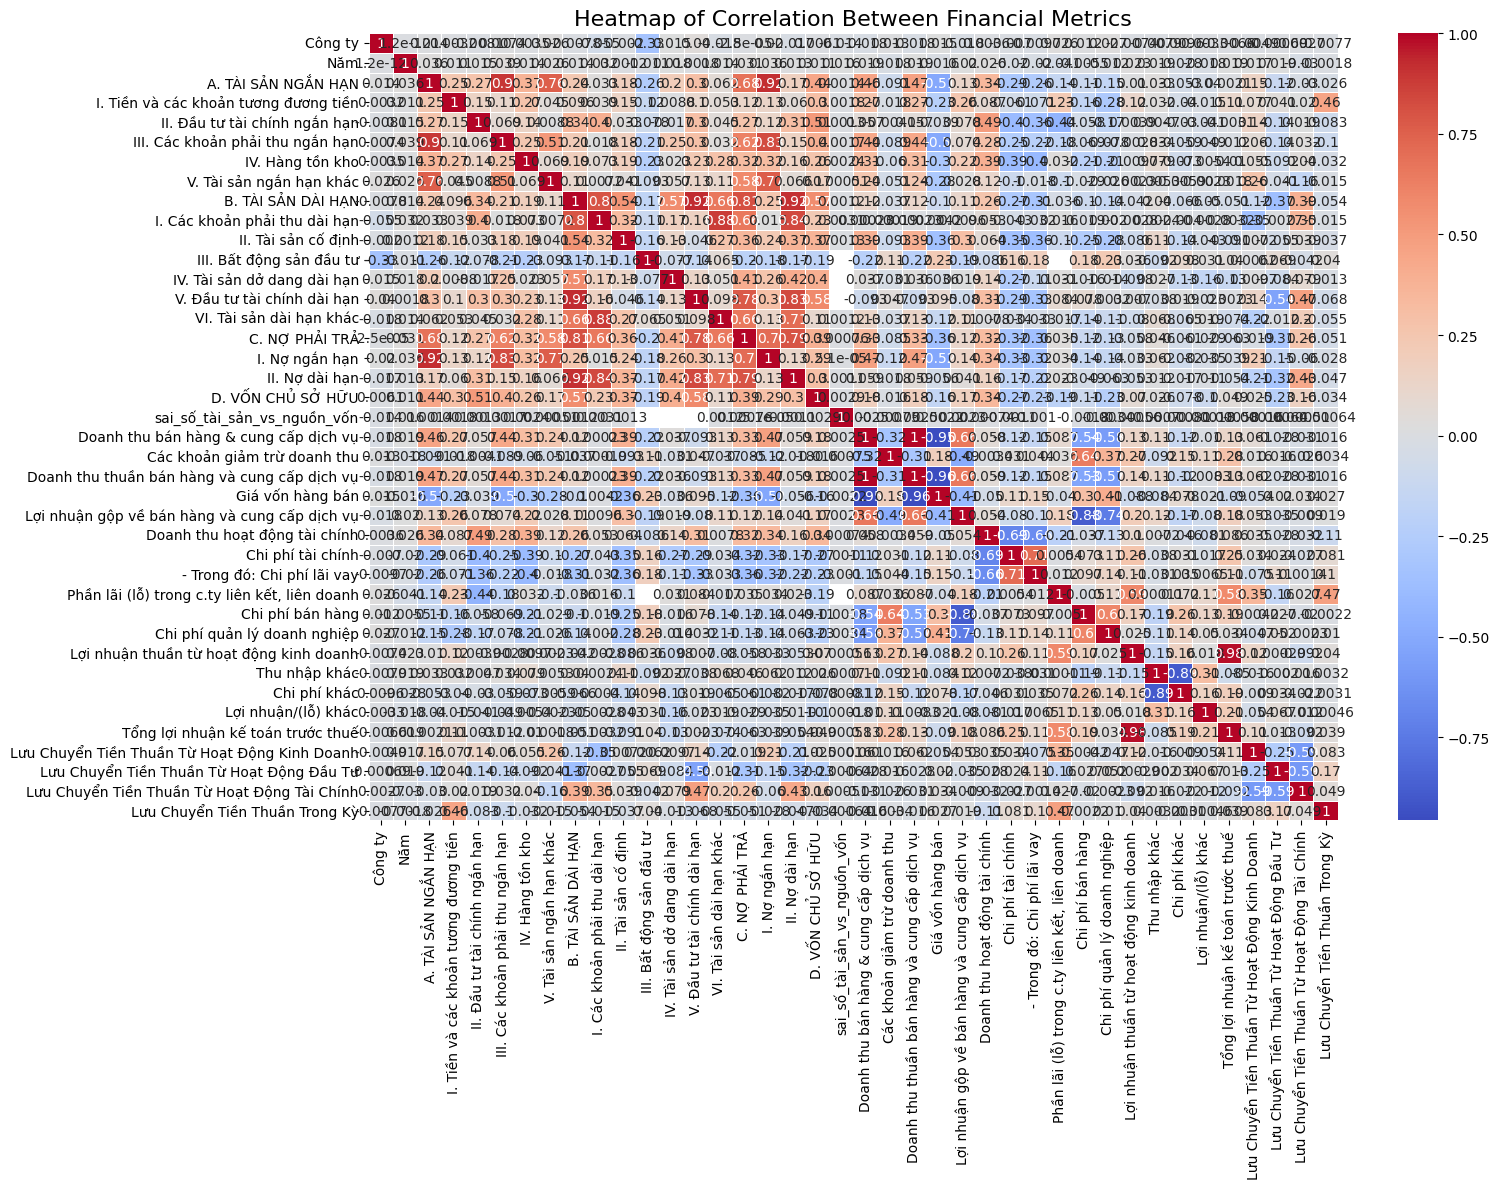

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chỉ lấy các cột số để tính correlation
numeric_df = merged_df.select_dtypes(include='number')

# Tính ma trận tương quan
corr_matrix = numeric_df.corr()

# Vẽ heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlation Between Financial Metrics', fontsize=16)
plt.tight_layout()
plt.show()

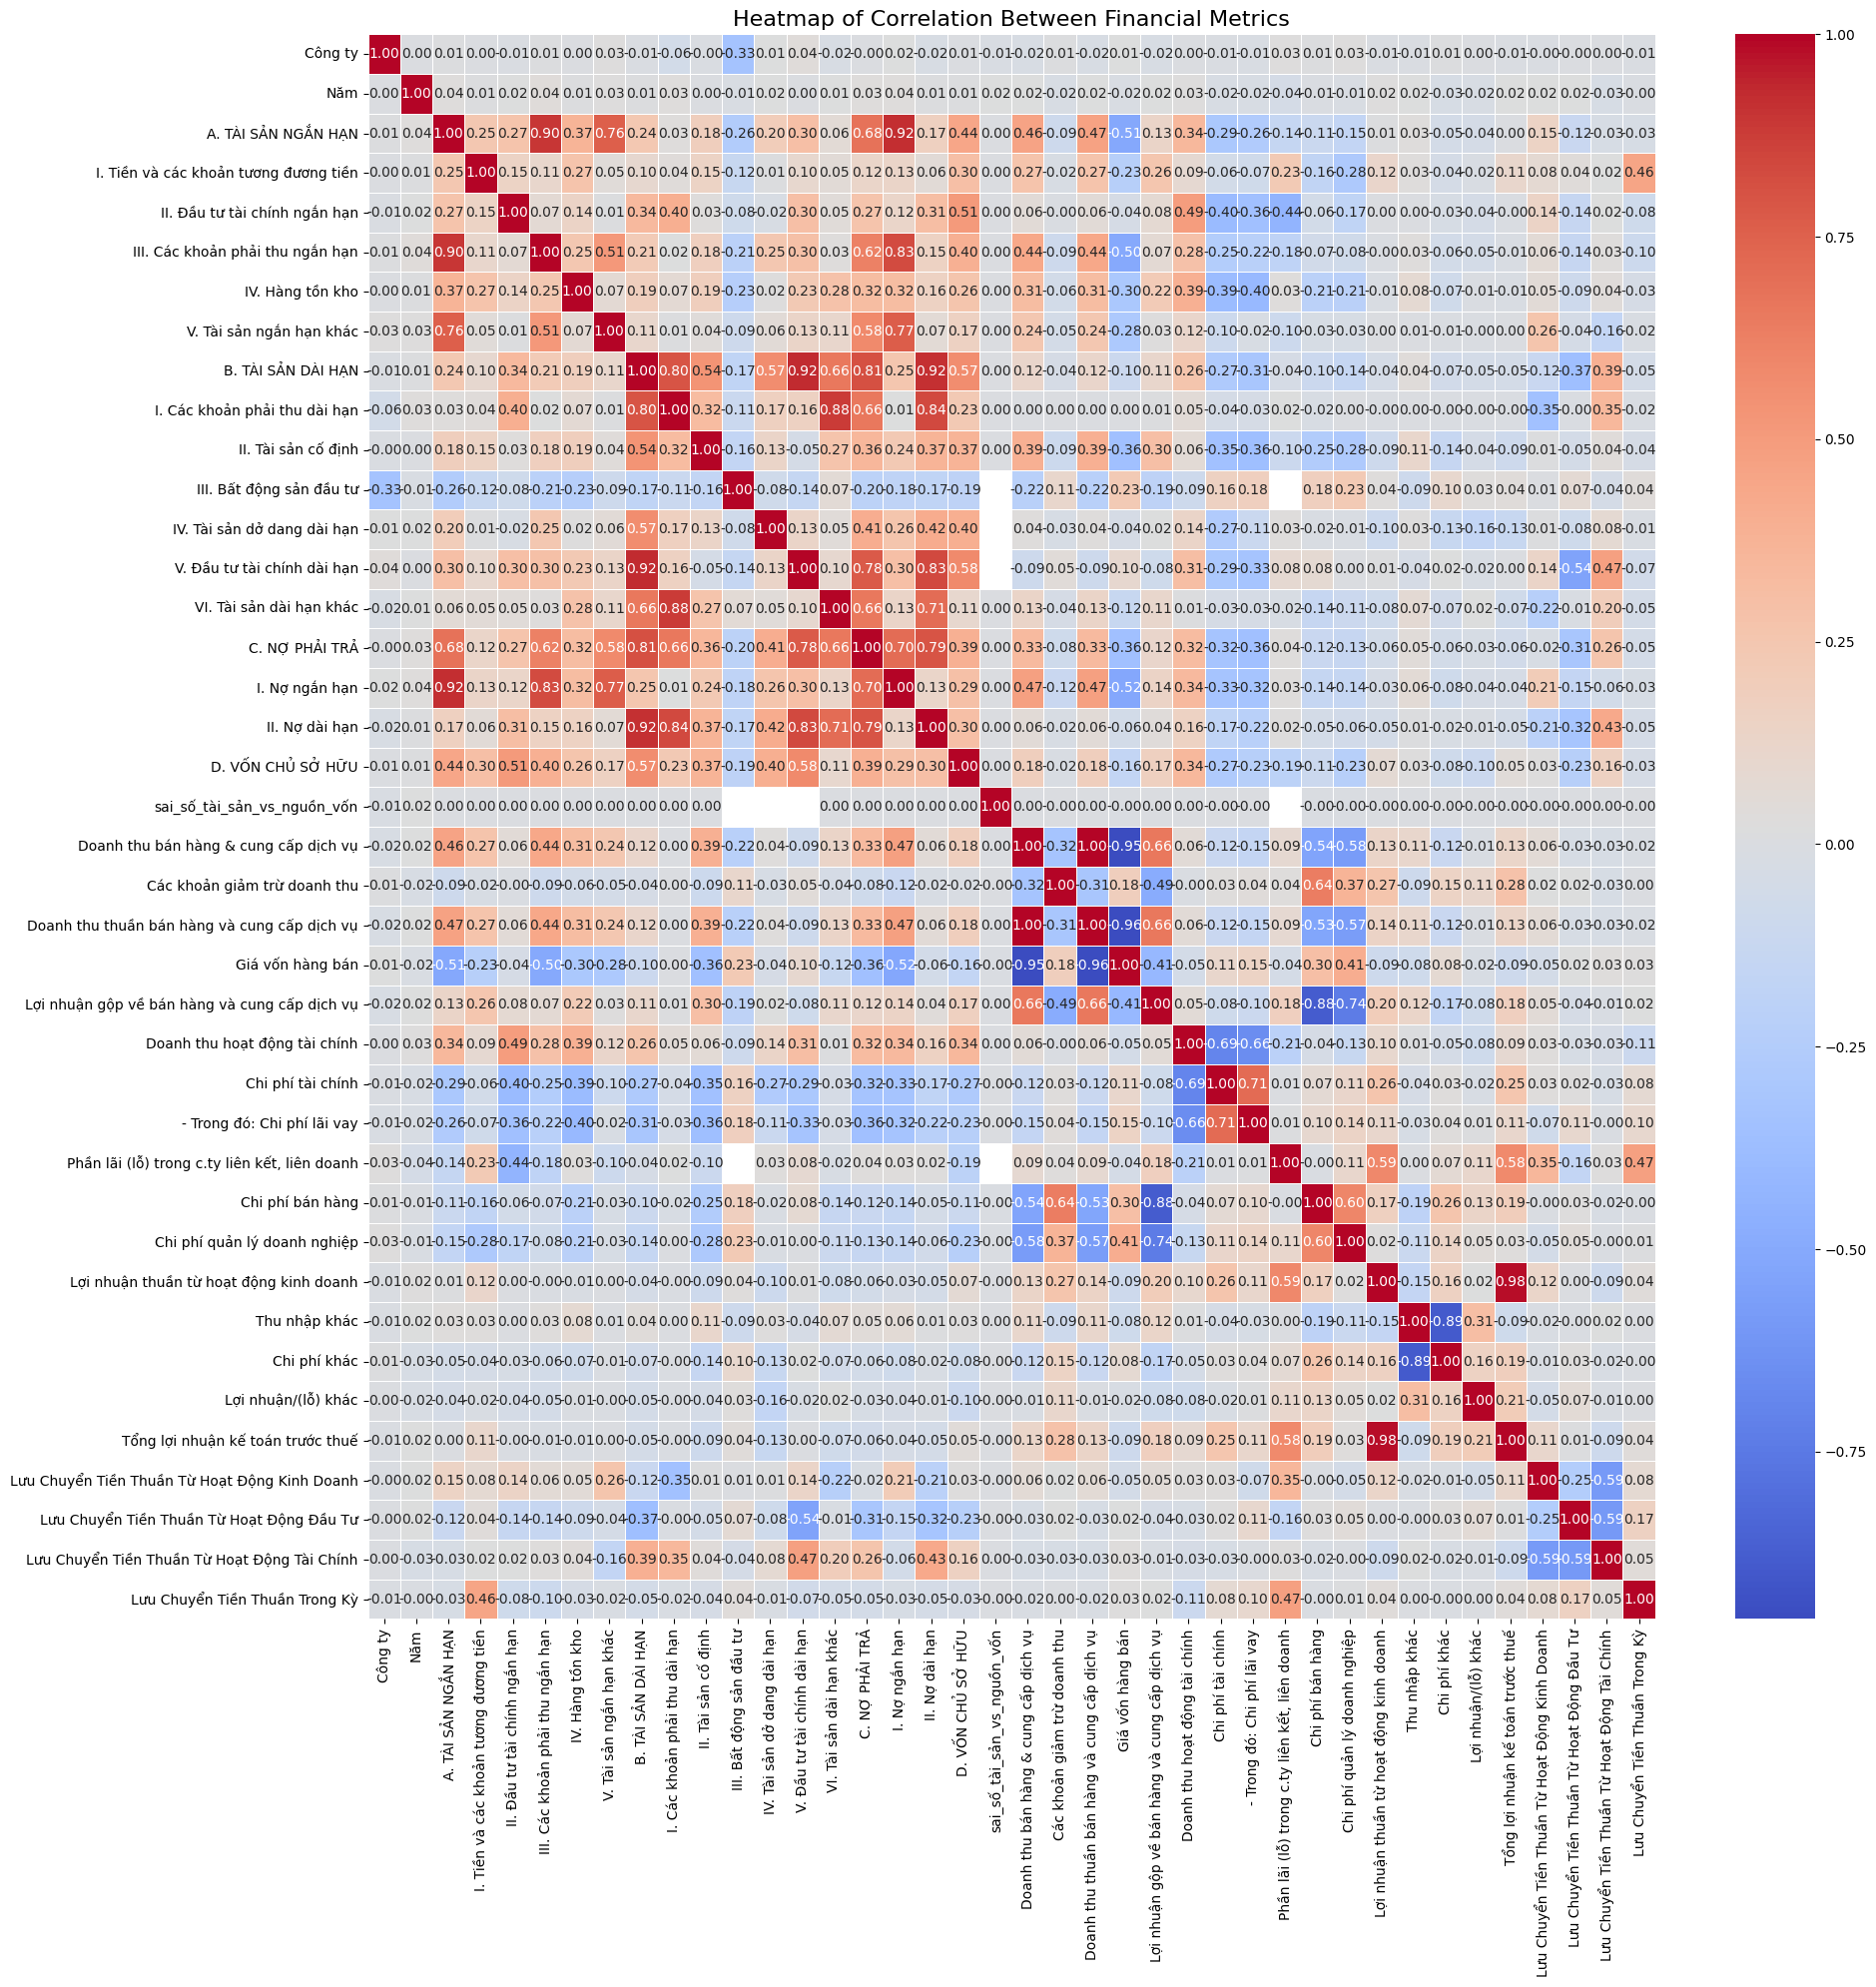

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlation Between Financial Metrics', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
balance_sheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Công ty                                8010 non-null   int64  
 1   Năm                                    8010 non-null   int64  
 2   A. TÀI SẢN NGẮN HẠN                    8007 non-null   float64
 3   I. Tiền và các khoản tương đương tiền  7988 non-null   float64
 4   II. Đầu tư tài chính ngắn hạn          4045 non-null   float64
 5   III. Các khoản phải thu ngắn hạn       5544 non-null   float64
 6   IV. Hàng tồn kho                       5881 non-null   float64
 7   V. Tài sản ngắn hạn khác               6769 non-null   float64
 8   B. TÀI SẢN DÀI HẠN                     7481 non-null   float64
 9   I. Các khoản phải thu dài hạn          1358 non-null   float64
 10  II. Tài sản cố định                    4467 non-null   float64
 11  III.

In [ ]:
balance_sheet.isna().sum()

NameError: name 'balance_sheet' is not defined

In [ ]:
# Lọc các dòng có đúng 3 trong 4 cột A, B, C, D là null
balance_sheet_filter = balance_sheet[balance_sheet[['A. TÀI SẢN NGẮN HẠN', 'B. TÀI SẢN DÀI HẠN', 'C. NỢ PHẢI TRẢ', 'D. VỐN CHỦ SỞ HỮU']].isnull().sum(axis=1) == 4]

In [ ]:
balance_sheet[balance_sheet['Công ty'] ==885]

,Công ty,Năm,A. TÀI SẢN NGẮN HẠN,I. Tiền và các khoản tương đương tiền,II. Đầu tư tài chính ngắn hạn,III. Các khoản phải thu ngắn hạn,IV. Hàng tồn kho,V. Tài sản ngắn hạn khác,B. TÀI SẢN DÀI HẠN,I. Các khoản phải thu dài hạn,II. Tài sản cố định,III. Bất động sản đầu tư,IV. Tài sản dở dang dài hạn,V. Đầu tư tài chính dài hạn,VI. Tài sản dài hạn khác,C. NỢ PHẢI TRẢ,I. Nợ ngắn hạn,II. Nợ dài hạn,D. VỐN CHỦ SỞ HỮU,sai_số_tài_sản_vs_nguồn_vốn
4420,885,2019,4.125722e+08,4.125722e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,412572213.0,412572213.0,0.0,NaN,NaN
4421,885,2020,5.123540e+06,5.123540e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5123540.0,5123540.0,0.0,NaN,NaN
4422,885,2021,6.000000e+06,6.000000e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6000000.0,6000000.0,0.0,NaN,NaN
4423,885,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4424,885,2023,5.000000e+09,5.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+09,NaN


In [ ]:
balance_sheet_filter

,Công ty,Năm,A. TÀI SẢN NGẮN HẠN,I. Tiền và các khoản tương đương tiền,II. Đầu tư tài chính ngắn hạn,III. Các khoản phải thu ngắn hạn,IV. Hàng tồn kho,V. Tài sản ngắn hạn khác,B. TÀI SẢN DÀI HẠN,I. Các khoản phải thu dài hạn,II. Tài sản cố định,III. Bất động sản đầu tư,IV. Tài sản dở dang dài hạn,V. Đầu tư tài chính dài hạn,VI. Tài sản dài hạn khác,C. NỢ PHẢI TRẢ,I. Nợ ngắn hạn,II. Nợ dài hạn,D. VỐN CHỦ SỞ HỮU,sai_số_tài_sản_vs_nguồn_vốn
230,47,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1880,377,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4423,885,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


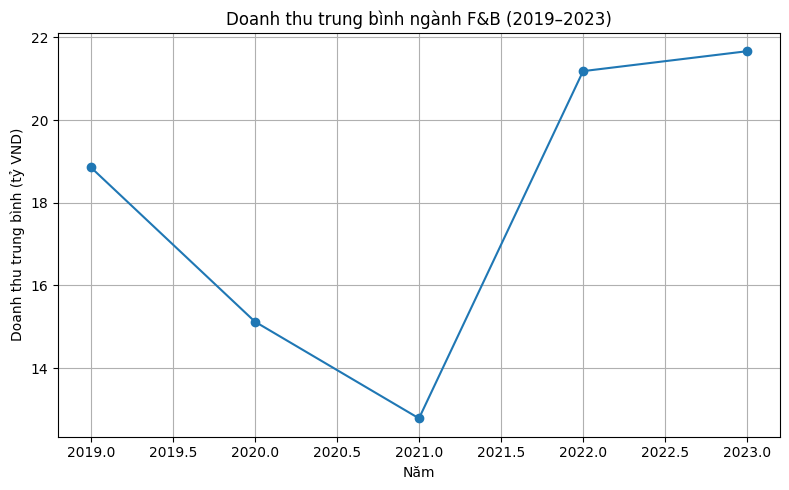

In [ ]:
# Sử dụng các tên cột gốc thay vì đổi tên

# 1. Lọc và sử dụng dữ liệu từ Income Statement
income_clean = income_statement[['Công ty', 'Năm', 'Doanh thu thuần bán hàng và cung cấp dịch vụ', 'Tổng lợi nhuận kế toán trước thuế']]

# 2. Lọc và sử dụng dữ liệu từ Balance Sheet
balance_sheet['A. TÀI SẢN NGẮN HẠN'] = pd.to_numeric(balance_sheet['A. TÀI SẢN NGẮN HẠN'], errors='coerce')
balance_sheet['B. TÀI SẢN DÀI HẠN'] = pd.to_numeric(balance_sheet['B. TÀI SẢN DÀI HẠN'], errors='coerce')
balance_sheet['Tổng tài sản'] = balance_sheet['A. TÀI SẢN NGẮN HẠN'] + balance_sheet['B. TÀI SẢN DÀI HẠN']
balance_clean = balance_sheet[['Công ty', 'Năm', 'Tổng tài sản']]

# 3. Lọc và sử dụng dữ liệu từ Cash Flow
cashflow_clean = cash_flow[['Công ty', 'Năm', 'Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh']]

# Gộp cả 3 bảng dựa trên 'Công ty' và 'Năm'
df_merged = income_clean.merge(balance_clean, on=['Công ty', 'Năm'], how='left')
df_merged = df_merged.merge(cashflow_clean, on=['Công ty', 'Năm'], how='left')

# Lọc giai đoạn 2019–2023 và loại bỏ dòng thiếu doanh thu
df_merged = df_merged[df_merged['Năm'].between(2019, 2023)].dropna(subset=['Doanh thu thuần bán hàng và cung cấp dịch vụ'])

# Tính doanh thu trung bình theo năm
avg_revenue = df_merged.groupby('Năm')['Doanh thu thuần bán hàng và cung cấp dịch vụ'].mean().reset_index()

# Vẽ biểu đồ doanh thu trung bình
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(avg_revenue['Năm'], avg_revenue['Doanh thu thuần bán hàng và cung cấp dịch vụ'] / 1e9, marker='o')
plt.title('Doanh thu trung bình ngành F&B (2019–2023)')
plt.xlabel('Năm')
plt.ylabel('Doanh thu trung bình (tỷ VND)')
plt.grid(True)
plt.tight_layout()
plt.show()


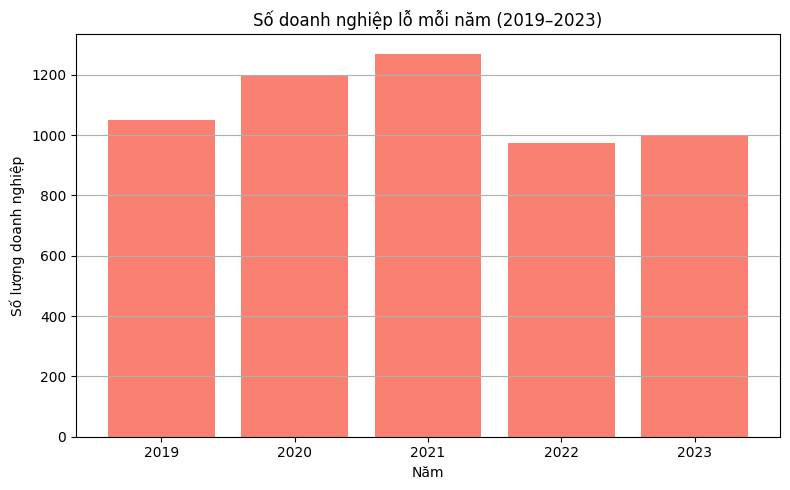

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


<Figure size 800x500 with 0 Axes>

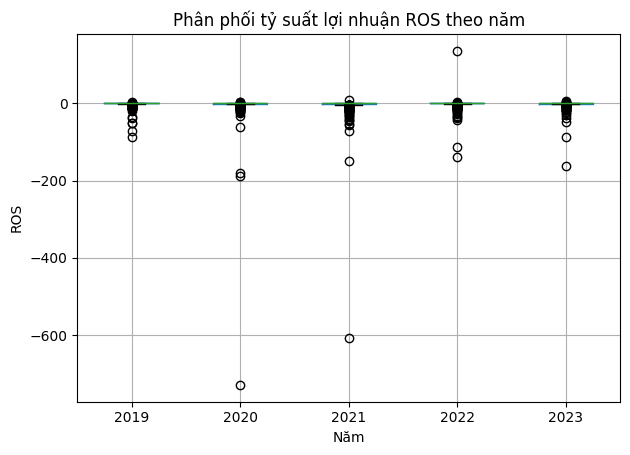

<Figure size 800x500 with 0 Axes>

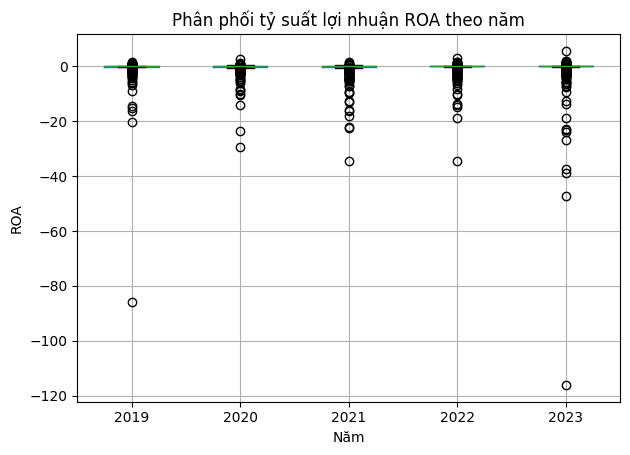

<Figure size 800x500 with 0 Axes>

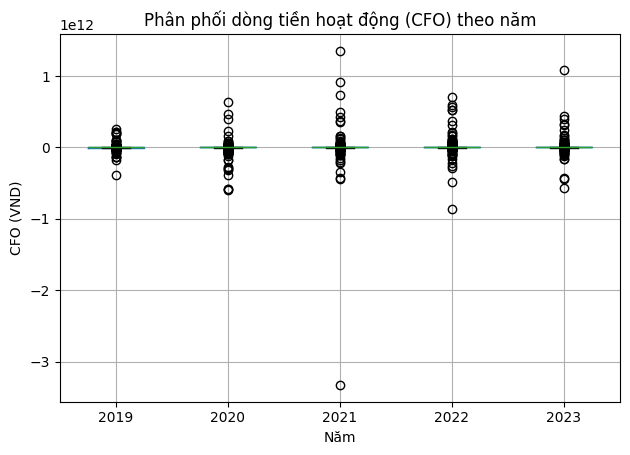

In [ ]:
# Tính ROS (Lợi nhuận ròng / Doanh thu) và ROA (Lợi nhuận ròng / Tổng tài sản)
df_merged['ROS'] = df_merged['Tổng lợi nhuận kế toán trước thuế'] / df_merged['Doanh thu thuần bán hàng và cung cấp dịch vụ']
df_merged['ROA'] = df_merged['Tổng lợi nhuận kế toán trước thuế'] / df_merged['Tổng tài sản']

# Tính số lượng doanh nghiệp có lợi nhuận < 0 mỗi năm
loss_counts = df_merged[df_merged['Tổng lợi nhuận kế toán trước thuế'] < 0].groupby('Năm')['Công ty'].count().reset_index()
loss_counts.columns = ['Năm', 'Số DN lỗ']

# Vẽ biểu đồ cột – Số doanh nghiệp lỗ mỗi năm
plt.figure(figsize=(8, 5))
plt.bar(loss_counts['Năm'], loss_counts['Số DN lỗ'], color='salmon')
plt.title('Số doanh nghiệp lỗ mỗi năm (2019–2023)')
plt.xlabel('Năm')
plt.ylabel('Số lượng doanh nghiệp')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Vẽ boxplot ROS theo năm
plt.figure(figsize=(8, 5))
df_merged.boxplot(column='ROS', by='Năm')
plt.title('Phân phối tỷ suất lợi nhuận ROS theo năm')
plt.suptitle('')
plt.xlabel('Năm')
plt.ylabel('ROS')
plt.tight_layout()
plt.show()

# Vẽ boxplot ROA theo năm
plt.figure(figsize=(8, 5))
df_merged.boxplot(column='ROA', by='Năm')
plt.title('Phân phối tỷ suất lợi nhuận ROA theo năm')
plt.suptitle('')
plt.xlabel('Năm')
plt.ylabel('ROA')
plt.tight_layout()
plt.show()

# Vẽ boxplot CFO (Lưu chuyển tiền thuần từ HĐKD) theo năm
plt.figure(figsize=(8, 5))
df_merged.boxplot(column='Lưu Chuyển Tiền Thuần Từ Hoạt Động Kinh Doanh', by='Năm')
plt.title('Phân phối dòng tiền hoạt động (CFO) theo năm')
plt.suptitle('')
plt.xlabel('Năm')
plt.ylabel('CFO (VND)')
plt.tight_layout()
plt.show()


# Export Data

In [ ]:
!pip install --upgrade -q gspread gspread-dataframe

import gspread
from gspread_dataframe import set_with_dataframe
from google.colab import auth
from google.auth import default
import pandas as pd

# Bước 1: Xác thực Google Account
auth.authenticate_user()

# Bước 2: Lấy credentials và kết nối Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Bước 3: Tạo file Google Sheets
spreadsheet = gc.create("Gcontest_2025_Cleaned_Data")

# Bước 4: Tạo từng worksheet với kích thước phù hợp với số dòng, cột thực tế
worksheet_bs = spreadsheet.add_worksheet(
    title="Balance Sheet",
    rows=str(len(balance_sheet_filled_all) + 10),
    cols=str(len(balance_sheet_filled_all.columns) + 5)
)

worksheet_is = spreadsheet.add_worksheet(
    title="Income Statement",
    rows=str(len(is_filled) + 10),
    cols=str(len(is_filled.columns) + 5)
)

worksheet_cf = spreadsheet.add_worksheet(
    title="Cash Flow",
    rows=str(len(cf_filled) + 10),
    cols=str(len(cf_filled.columns) + 5)
)

# Bước 5: Ghi dữ liệu
set_with_dataframe(worksheet_bs, balance_sheet_filled_all)
set_with_dataframe(worksheet_is, is_filled)
set_with_dataframe(worksheet_cf, cf_filled)

# Bước 6: Xoá Sheet1 mặc định
default_ws = spreadsheet.worksheet("Sheet1")
spreadsheet.del_worksheet(default_ws)

# Bước 7: In link Google Sheet
print("📎 Link file Google Sheets:", spreadsheet.url)


📎 Link file Google Sheets: https://docs.google.com/spreadsheets/d/1VAfzj4JjUVmY0Cy7BHDhmQnxqf93EI0XZvPGe1rmfPM
